Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**


In [ ]:
!pip install torchaudio
!pip install  pydub
import os
import torch
import torchaudio
import tarfile
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchaudio.datasets import GTZAN
from torch.utils.data import DataLoader
import torchaudio.transforms as transforms
from torch.utils.data import random_split
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline



# TP3: Encodeador de música



## Orden de pasos

0. Elijan GPU para que corra mas rapido (RAM --> change runtime type --> T4 GPU)
1. Descargamos el dataset y lo descomprimimos en alguna carpeta en nuestro drive.
2. Conectamos la notebook a gdrive y seteamos data_dir con el path a los archivos.
3. Visualización de los archivos
4. Clasificación
5. Evaluación




### 2. Conectamos la notebook a gdrive y seteamos data_dir con el path a los archivos.





In [ ]:
#monta Google Drive en la máquina de Google Colab para acceder a archivos almacenados en tu unidad.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Este código lista todas las carpetas dentro de data_dir, cada una de las cuales representa un género musical. Si una carpeta es un directorio, se agrega a la lista classes.

import os
data_dir='//content/drive/MyDrive/data_TP3_TD6'
list_files=os.listdir(data_dir)
classes=[]
for file in list_files:
  name='{}/{}'.format(data_dir,file)
  if os.path.isdir(name):
    classes.append(file)
classes

['disco',
 'jazz',
 'blues',
 'classical',
 'hiphop',
 'country',
 'rock',
 'metal',
 'reggae',
 'pop']

 Configuración de la frecuencia de muestreo y definición de la función de parsing de géneros:

In [ ]:
samplerate=22050 #La frecuencia de muestreo se establece en 22050 Hz

#La función parse_genres toma el nombre del archivo y extrae el género basado en el nombre del archivo
def parse_genres(fname):
    parts = fname.split('/')[-1].split('.')[0]
    return parts #' '.join(parts[0])

class MusicDataset(Dataset):
    def __init__(self, root):
        super().__init__()
        self.root = root
        self.files = []
        self.transform = transforms.Spectrogram()  # Definir la transformación a espectrograma
        for c in classes:
            self.files += [fname for fname in os.listdir(os.path.join(root, c)) if fname.endswith('.wav')]
        self.classes = list(set(parse_genres(fname) for fname in self.files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        fname = self.files[i]
        genre = parse_genres(fname)
        fpath = os.path.join(self.root, genre, fname)
        class_idx = self.classes.index(genre)
        audio = torchaudio.load(fpath)[0]

        # Aplicar la transformación a espectrograma
        spec = self.transform(audio)

        return spec.squeeze(0), class_idx  # Retornar el espectrograma y la clase
dataset = MusicDataset(data_dir)

### 3. Visualización de los archivos

In [ ]:
waveform,label= dataset[0]
print("shape of waveform {}, sample rate with {}, label is {} ".format(waveform.size(),samplerate,label))

shape of waveform torch.Size([201, 552]), sample rate with 22050, label is 3 


shape of spectrogram: torch.Size([201, 552])


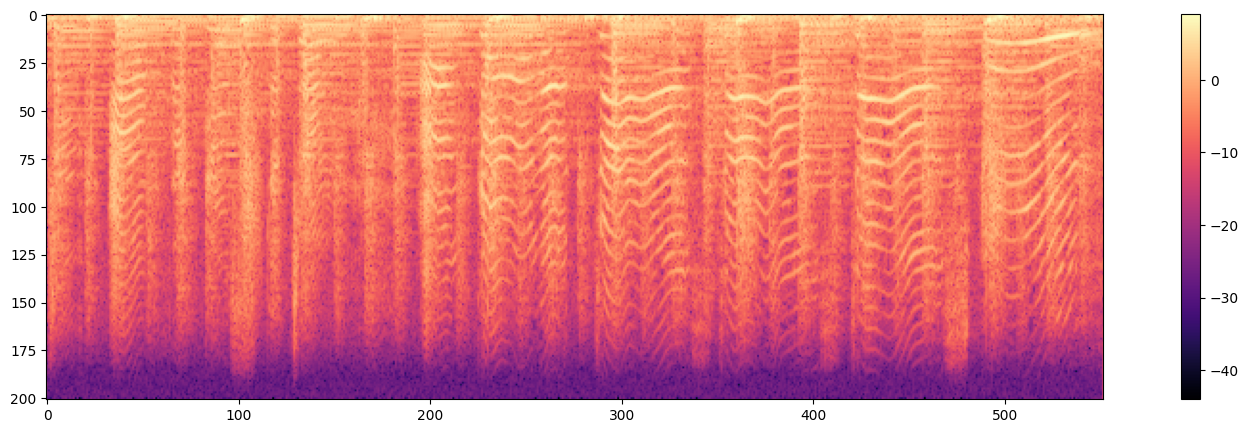

In [ ]:
# Calcular el espectrograma
specgram = waveform  # Eliminar la dimensión del canal, cambiando la forma a (201, 552)
print("shape of spectrogram:", specgram.size())

# Visualizar el espectrograma completo
plt.figure(figsize=(20, 5))
plt.imshow(specgram.log2().numpy(), cmap='magma')  # Aplicar log2 para reducir el rango dinámico
plt.colorbar()
plt.show()


Valores de la señal original (waveform): tensor([[0.0350, 0.0344, 0.0350, 0.0378, 0.0385, 0.0360, 0.0306, 0.0237, 0.0197,
         0.0176]])


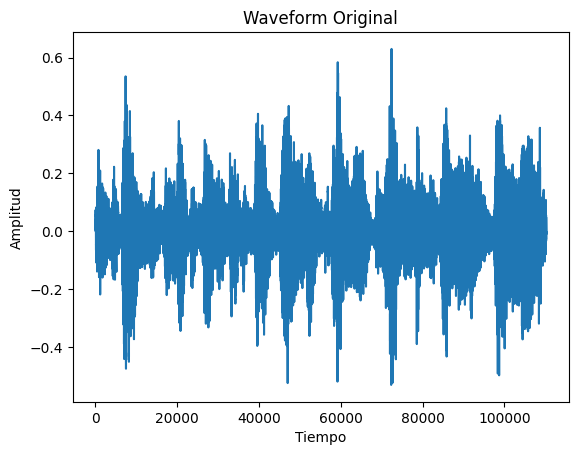

In [ ]:
# Cargar el audio sin transformarlo a espectrograma
audio_path = dataset.root + '/' + classes[0] + '/' + dataset.files[0]
waveform, sample_rate = torchaudio.load(audio_path)

# Imprimir una pequeña muestra de los datos del waveform
print("Valores de la señal original (waveform):", waveform[:, :10])  # Muestra los primeros 10 valores

# Graficar la señal original (waveform) antes de la transformación
plt.figure()
plt.plot(waveform[0].numpy())  # Graficar el primer canal
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Waveform Original")
plt.show()


Escuchamos el espectograma con la librería de audio

In [ ]:
import IPython
import torchaudio

# Seleccionar el primer canal si es estéreo (para asegurarse de que es un arreglo 1D)
audio_data = waveform[0].numpy()  # Seleccionar el primer canal y convertir a numpy

# Reproducir el audio
IPython.display.Audio(audio_data, rate=sample_rate)

In [ ]:
specgram.size()

torch.Size([201, 552])

In [ ]:
random_seed = 42
torch.manual_seed(random_seed);
val_size = 100
test_size = 100
train_size = len(dataset) - val_size - test_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
len(dataset),len(train_ds),len(val_ds),len(test_ds)

(990, 790, 100, 100)

In [ ]:
from torch.utils.data import DataLoader
batch_size = 10

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
valid_dl = DataLoader(val_ds, batch_size, num_workers=4, pin_memory=True)
test_dl = DataLoader(test_ds,1, num_workers=4, pin_memory=True)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### 4. Clasificación

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, n_output=10):
        super(CNN, self).__init__()
        # Cuatro capas convolucionales
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # Capas densas de salida, ajustando la entrada de fc1 al tamaño correcto
        self.fc1 = nn.Linear(256 * 12 * 34, 256)  # Ajusta los valores según el tamaño de salida
        self.fc2 = nn.Linear(256, n_output)

    def forward(self, x):
        x = self.pool(torch.tanh(self.conv1(x)))
        x = self.pool(torch.tanh(self.conv2(x)))
        x = self.pool(torch.tanh(self.conv3(x)))
        x = self.pool(torch.tanh(self.conv4(x)))  # Nueva capa activada con tanh

        x = x.view(x.size(0), -1)  # Ajuste para el tamaño de la entrada de fc1
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)  # La última capa suele quedarse sin función de activación en problemas de clasificación
        return x

In [ ]:
len(classes)

10

In [ ]:
import wandb
import torch
import numpy as np
import gc
from sklearn.metrics import accuracy_score, confusion_matrix
import torch.nn.functional as F

# Inicializar W&B con el nombre del experimento
wandb.init(project="Music_genre_classification", name="CNN_4capasconv_10_batch_10_epoch_tanh_Adam_StepLR_evaluacionfinal")

# Configuración del modelo y los parámetros
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = CNN(n_output=len(classes)).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

num_epochs = 10

# Para registrar el número de parámetros en W&B
n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of parameters: {n}")
wandb.config.update({"num_parameters": n})

valid_losses = []
torch.cuda.empty_cache()
gc.collect()

for epoch in range(num_epochs):
    # Entrenamiento
    model.train()
    train_losses = []
    for wav, genre_index in train_dl:
        wav, genre_index = wav.to(device), torch.as_tensor(genre_index).to(device)
        optimizer.zero_grad()
        out = model(wav.unsqueeze(1))
        loss = loss_function(out, genre_index)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Liberar memoria
        del wav, genre_index, loss, out
        torch.cuda.empty_cache()
        gc.collect()

    train_loss = np.mean(train_losses)
    print(f'Epoch: [{epoch+1}/{num_epochs}], Train loss: {train_loss:.4f}')

    # Validación
    model.eval()
    val_losses = []
    correct = 0
    with torch.no_grad():
        for wav, genre_index in valid_dl:
            wav, genre_index = wav.to(device), genre_index.to(device)
            out = model(wav.unsqueeze(1))
            loss = loss_function(out, genre_index)
            val_losses.append(loss.item())
            pred = out.argmax(dim=-1).flatten()
            correct += pred.eq(genre_index).sum().item()

            # Liberar memoria
            del wav, genre_index, loss, out
            torch.cuda.empty_cache()
            gc.collect()

    valid_loss = np.mean(val_losses)
    accuracy = correct / len(valid_dl.dataset)
    print(f'Epoch: [{epoch+1}/{num_epochs}], Valid loss: {valid_loss:.4f}, Valid accuracy: {accuracy:.4f}')

    # Actualizar scheduler cada época
    scheduler.step()

    # Registrar en W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": valid_loss,
        "val_accuracy": accuracy,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # Guardar el mejor modelo
    valid_losses.append(valid_loss)
    if np.argmin(valid_losses) == epoch:
        print(f'Saving the best model at epoch {epoch + 1}!')
        torch.save(model.state_dict(), 'best_model.ckpt')


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,██▄▄▄▂▂▂▁▁
train_loss,█▆▄▂▂▁▁▁▁▁
val_accuracy,▁▁▇▆█▆▇▇▇▆
val_loss,█▆▂▂▂▁▂▂▂▂
epoch,10
learning_rate,1e-05
train_loss,0.09281
val_accuracy,0.55
val_loss,1.33072


Number of parameters: 27129354
Epoch: [1/10], Train loss: 1.8944
Epoch: [1/10], Valid loss: 1.6652, Valid accuracy: 0.4000
Saving the best model at epoch 1!
Epoch: [2/10], Train loss: 1.3253
Epoch: [2/10], Valid loss: 1.3574, Valid accuracy: 0.4700
Saving the best model at epoch 2!
Epoch: [3/10], Train loss: 0.8494
Epoch: [3/10], Valid loss: 1.2848, Valid accuracy: 0.5800
Saving the best model at epoch 3!
Epoch: [4/10], Train loss: 0.4586
Epoch: [4/10], Valid loss: 1.2099, Valid accuracy: 0.6100
Saving the best model at epoch 4!
Epoch: [5/10], Train loss: 0.3066
Epoch: [5/10], Valid loss: 1.1906, Valid accuracy: 0.6100
Saving the best model at epoch 5!
Epoch: [6/10], Train loss: 0.2168
Epoch: [6/10], Valid loss: 1.2814, Valid accuracy: 0.5600
Epoch: [7/10], Train loss: 0.1472
Epoch: [7/10], Valid loss: 1.2469, Valid accuracy: 0.6100
Epoch: [8/10], Train loss: 0.1262
Epoch: [8/10], Valid loss: 1.2557, Valid accuracy: 0.5800
Epoch: [9/10], Train loss: 0.1061
Epoch: [9/10], Valid loss: 1.



### 5. Evaluación



In [34]:
test_dl = DataLoader(test_ds,1,shuffle=True, num_workers=4, pin_memory=True)

In [35]:
# Load the best model
S = torch.load('best_model.ckpt')
model.load_state_dict(S)
print('loaded!')

# Run evaluation
model.eval()
y_true = []
y_pred = []
correct = 0
with torch.no_grad():
    for wav, genre_index in test_dl:
        wav = wav.to(device)
        genre_index = genre_index.to(device)

        out = model(wav.unsqueeze(1))

        pred= out.argmax(dim=-1).flatten()
        # append labels and predictions
        correct += pred.eq(genre_index).sum().item()
        y_true.extend(genre_index)
        y_pred.extend(pred)

accuracy =correct/ len(test_dl.dataset)
print('Epoch: [%d/%d], Valid loss: %.4f, Test accuracy: %.4f' % (epoch+1, num_epochs, valid_loss, accuracy))


loaded!


<ipython-input-35-00816e3b436c>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  S = torch.load('best_model.ckpt')


Epoch: [10/10], Valid loss: 1.2766, Valid accuracy: 0.5400


In [36]:
waveform,label= test_dl.dataset[12]
print("shape of waveform {}, sample rate with {}, label is {} ".format(waveform.size(),samplerate,label))

shape of waveform torch.Size([201, 552]), sample rate with 22050, label is 1 


In [38]:
import IPython
IPython.display.Audio(waveform, rate=22050)

In [39]:
wav= torch.unsqueeze(waveform, dim=0)
model.to(device)
wav =wav.to(device)
out = model(wav.unsqueeze(1))
pred= out.argmax(dim=-1).flatten()
classes[pred], classes[label]

('hiphop', 'jazz')